## Graphs

There are three graphs worth looking at. 

1. How prices change Vs renewable energy output.
2. How many times prices have gone negative per year.
3. Differenciating between crisis (during 2022) and non crisis values to prevent them from distorting our analysis.

Setup:
1. Resample all series weekly.
2. Merge renewables solar, wind onshore and wind offshore and plot them against daily average prices.

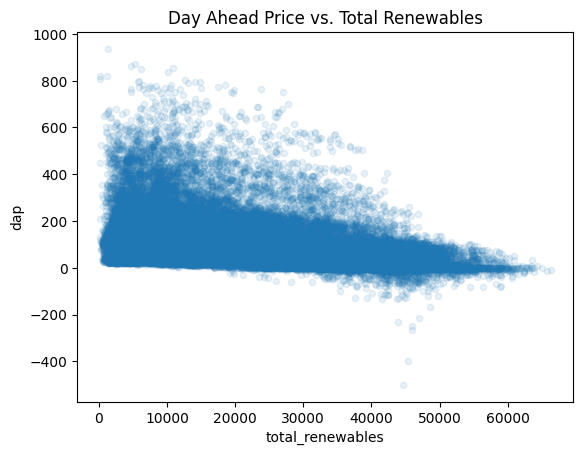

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.close("all")

day_ahead = pd.read_parquet("C:/dev/smard-merit-order/data/day_ahead.parquet")
dar = day_ahead.resample('W', on='timestamp')['dap'].mean()
# dar.plot(x='timestamp', y='dap', title='Day Ahead Prices')

grid_load = pd.read_parquet("C:/dev/smard-merit-order/data/grid_load.parquet")
glr = grid_load.resample('W', on='timestamp')['gl'].mean()
# glr.plot(x='timestamp', y='grid_load', title='Grid Load')

solar = pd.read_parquet("C:/dev/smard-merit-order/data/solar.parquet")
sr = solar.resample('W', on='timestamp')['slr'].mean()
# sr.plot(x='timestamp', y='solar', title='Solar')

wind_onshore = pd.read_parquet("C:/dev/smard-merit-order/data/wind_onshore.parquet")
wor = wind_onshore.resample('W', on='timestamp')['won'].mean()
# wor.plot(x='timestamp', y='wind_onshore', title='Wind Onshore')

wind_offshore = pd.read_parquet("C:/dev/smard-merit-order/data/wind_offshore.parquet")
wfr = wind_offshore.resample('W', on='timestamp')['wof'].mean()
# wfr.plot(x='timestamp', y='wind_offshore', title='Wind Offshore')

merged = pd.read_parquet("C:/dev/smard-merit-order/data/merged_data.parquet")
merged['total_renewables'] = merged['slr'] + merged['won'] + merged['wof']
merged.plot.scatter(x='total_renewables', y='dap', title='Day Ahead Price vs. Total Renewables', alpha=0.1)
plt.show()

Making a binary column which contains the number of negative values in a year.

<Axes: xlabel='timestamp'>

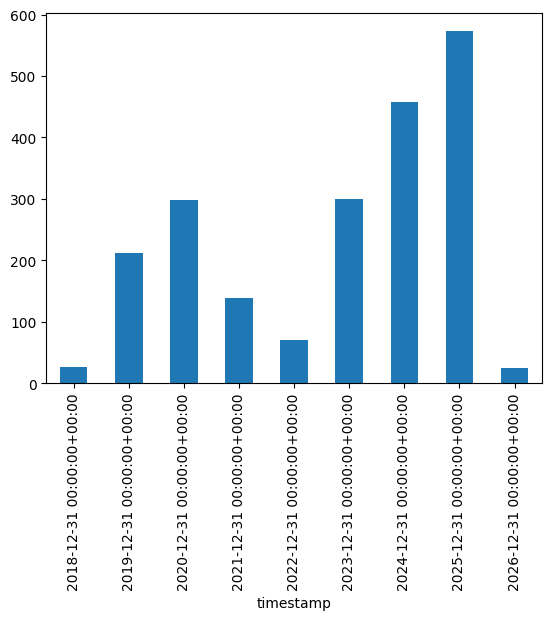

In [2]:
merged["is_negative"] = pd.NA
merged['is_negative'] = merged['dap'] < 0
merged_resampled_anually = merged.resample('YE', on='timestamp')['is_negative'].sum()
merged_resampled_anually.plot.bar()

Add a column to differenciate between pre crisis, crisis (March 2022 - December 2022) and post crisis.

In [ ]:
conditions = [
    merged['timestamp'] < '2021-06-01',
    (merged['timestamp'] >= '2021-06-01') & (merged['timestamp'] < '2022-12-01'),
    merged['timestamp'] >= '2022-12-01'
]

choices = ['Pre-crisis', 'Crisis', 'Post-crisis']

merged['period'] = np.select(conditions, choices, default='Unknown')

plt.figure(figsize=(12, 8))
colors = {'Pre-crisis': 'blue', 'Crisis': 'red', 'Post-crisis': 'green'}

for period in choices:
    subset = merged[merged['period'] == period]
    plt.scatter(
        subset['total_renewables'], 
        subset['dap'], 
        label=period, 
        color=colors[period], 
        alpha=0.1
    )

plt.title('Day Ahead Price vs. Total Renewables by Period')
plt.xlabel('Total Renewables')
plt.ylabel('Day Ahead Price')

legend = plt.legend(title='Period')
for handle in legend.legend_handles:
    handle.set_alpha(1.0)

plt.show()

This clearly shows that crisis time was an outlier and justifies having it's own dummy variable in the regression.

In [ ]:
merged_v2 = merged.sort_values('timestamp').reset_index(drop=True)
merged_v2['timestamp'] = merged_v2['timestamp'].dt.tz_localize(None)
merged_v2.to_excel("C:/Dev/smard-merit-order/data/merged_v2.xlsx", index=False)
merged_v2.to_parquet("C:/Dev/smard-merit-order/data/merged_v2.parquet", index=False)